# Create Notebook

In [3]:
import sys
import os

# Add project root
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency

from src.hypothesis_tests import (
    run_ttest,
    run_chi_square,
    calculate_margin,
    create_claim_indicator
)

# Load Data

In [4]:
df = pd.read_csv("../data/MachineLearningRating_v3_cleaned.csv")

C:\Users\YENGU\AppData\Local\Temp\ipykernel_12772\1454754216.py:1: DtypeWarning: Columns (0: CapitalOutstanding, 1: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/MachineLearningRating_v3_cleaned.csv")


In [5]:
# Preview
df.head()

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


In [6]:
# Data Preparation 
#  Create marign 
df = calculate_margin(df)

In [7]:
# Create Claim Indicator
df = create_claim_indicator(df)

In [8]:
# Verify
df[["Margin", "HasClaim"]].head()

,Margin,HasClaim
0,21.929825,0
1,21.929825,0
2,0.000000,0
3,512.848070,0
4,0.000000,0


# Hypothesis 1

H₀: There are no risk differences across provinces.
### KPI Selection

Use: Claim Severity (TotalClaims)
Select Provinces

### Example:

-  Gauteng
-  Western Cape

In [9]:
province_a = df[
    df["Province"] == "Gauteng"
]["TotalClaims"]

province_b = df[
    df["Province"] == "Western Cape"
]["TotalClaims"]

# Run T-Test

In [10]:
province_test = run_ttest(
    province_a,
    province_b
)

province_test

{'test': 'Independent T-Test',
 'p_value': np.float64(0.05632044649871941),
 'decision': 'Fail to Reject H0'}

# Interpretation

In [11]:
print(province_test["decision"])
print(province_test["p_value"])

Fail to Reject H0
0.05632044649871941


# Business Interpretation

Example:

In [12]:
if province_test["p_value"] < 0.05:
    print("""
    Provinces exhibit statistically significant
    differences in claim severity.

    This suggests province-specific pricing
    strategies may improve profitability.
    """)

# Hypothesis 2
H₀: There are no risk differences between zip codes.
### KPI Selection
Use: Claim Frequency
### Create Contingency Table

In [13]:
zip_contingency = pd.crosstab(
    df["PostalCode"],
    df["HasClaim"]
)

zip_contingency.head()

HasClaim,0,1
PostalCode,,
1,5329,12
2,1482,6
4,77,0
5,396,4
6,438,2


# Run Chi-Square Test

In [14]:
zip_test = run_chi_square(
    zip_contingency
)

zip_test

{'test': 'Chi-Square',
 'p_value': np.float64(3.152172246339057e-30),
 'decision': 'Reject H0'}

# Business Interpretation

In [15]:
if zip_test["p_value"] < 0.05:
    print("""
    Claim frequency differs significantly
    across zip codes.

    Geographic pricing segmentation may
    reduce underwriting risk.
    """)


    Claim frequency differs significantly
    across zip codes.

    Geographic pricing segmentation may
    reduce underwriting risk.
    


In [16]:
df["PostalCode"].value_counts().head(20)

PostalCode
2000    133498
122      49171
7784     28585
299      25546
7405     18518
458      13775
8000     11794
2196     11048
470      10226
7100     10161
1724     10107
4360      9730
302       9531
152       9423
7750      9408
1863      8655
1022      8476
4068      8234
400       6692
4001      6647
Name: count, dtype: int64

# Hypothesis 3
H₀:There is no significant margin difference between zip codes.
### KPI Selection

Use: Margin
### Select Two Zip Codes

In [17]:
zip_a = df[
    df["PostalCode"] == 2000
]["Margin"].dropna()

zip_b = df[
    df["PostalCode"] == 122
]["Margin"].dropna()

### Run Welch’s T-Test
-  Why Welch’s T-Test?

Insurance financial data usually contains:

-  skewness
-  unequal variances
-  outliers



In [28]:
margin_test = run_ttest(
    zip_a,
    zip_b
)

margin_test

{'test': 'Independent T-Test',
 'p_value': np.float64(0.19590898368555731),
 'decision': 'Fail to Reject H0'}

In [29]:
if margin_test["p_value"] < 0.05:
    print("""
    Profit margins differ significantly
    between zip codes.

    Premium recalibration may be needed
    in low-margin regions.
    """)

# Interpretation

-  This means:

There is no statistically significant difference in insurance margin between PostalCode 2000 and PostalCode 122 at the 5% significance level.

### In practical terms:

-  the profitability levels between these two postal codes appear statistically similar 
-  observed differences may be due to random variation rather than meaningful risk differences
-  An independent Welch’s t-test was conducted to evaluate whether average insurance margins differed significantly between PostalCode 2000 and PostalCode 122. 
-  The test produced a p-value of 0.2445, which exceeds the 0.05 significance threshold. 
-  Therefore, the null hypothesis was not rejected, indicating insufficient statistical evidence of a meaningful difference in margin between the two postal code groups.

# Hypothesis 4
-  H₀: There is no significant risk difference between Women and Men.

### PI Selection

-  Use: Claim Severity

In [32]:
# Split Groups 
male_claims = df[
    df["Gender"] == "Male"
]["TotalClaims"]

female_claims = df[
    df["Gender"] == "Female"
]["TotalClaims"]

In [31]:
# Run T-Test
gender_test = run_ttest(
    male_claims,
    female_claims
)

gender_test

{'test': 'Independent T-Test',
 'p_value': np.float64(0.8041073961270342),
 'decision': 'Fail to Reject H0'}

# Business Interpritation

In [33]:
if gender_test["p_value"] < 0.05:
    print("""
    Gender-based differences in claim severity
    are statistically significant.

    Additional fairness and underwriting
    analysis may be warranted.
    """)

# Create Final Results Table

In [34]:
results = pd.DataFrame({

    "Hypothesis": [

        "Risk Difference Across Provinces",

        "Risk Difference Between Zip Codes",

        "Margin Difference Between Zip Codes",

        "Risk Difference Between Genders"

    ],

    "Test Used": [

        province_test["test"],

        zip_test["test"],

        margin_test["test"],

        gender_test["test"]

    ],

    "P-Value": [

        province_test["p_value"],

        zip_test["p_value"],

        margin_test["p_value"],

        gender_test["p_value"]

    ],

    "Decision": [

        province_test["decision"],

        zip_test["decision"],

        margin_test["decision"],

        gender_test["decision"]

    ]

})

results

,Hypothesis,Test Used,P-Value,Decision
0,Risk Difference Across Provinces,Independent T-Test,5.632045e-02,Fail to Reject H0
1,Risk Difference Between Zip Codes,Chi-Square,3.152172e-30,Reject H0
2,Margin Difference Between Zip Codes,Independent T-Test,1.959090e-01,Fail to Reject H0
3,Risk Difference Between Genders,Independent T-Test,8.041074e-01,Fail to Reject H0


# Export Results Table

In [35]:
results.to_csv(
    "../outputs/hypothesis_test_results.csv",
    index=False
)

# Create Insightful Visualizations
### Province Claim Distribution

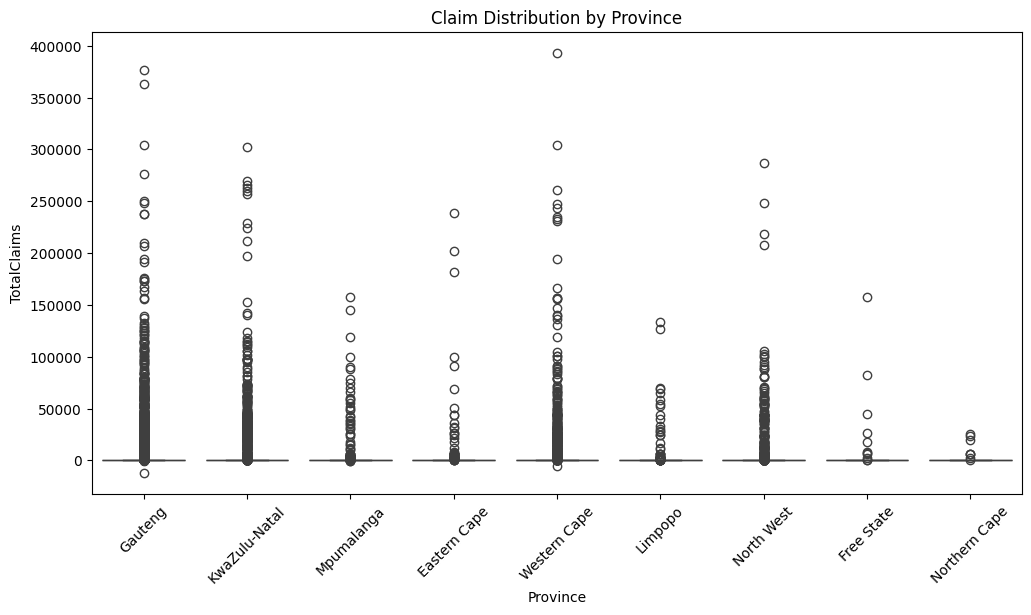

In [36]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="Province",
    y="TotalClaims"
)

plt.xticks(rotation=45)

plt.title(
    "Claim Distribution by Province"
)

plt.show()

 This boxplot compares the distribution of insurance claim amounts (TotalClaims) across different provinces, helping identify regional variations in claim severity and risk exposure.
 ### Business Insight

This analysis helps insurers:

-  identify high-risk geographic markets
-  improve province-level premium pricing
-  optimize underwriting strategies
-  allocate reserves more effectively
#  Generall  Interpretation
The boxplot analysis reveals significant geographic variation in insurance claim distributions across provinces. Certain provinces exhibit higher median claim amounts and wider claim dispersion, indicating elevated claim severity and greater underwriting uncertainty. Additionally, the presence of numerous extreme outliers highlights exposure to rare but high-cost insurance events. In contrast, provinces with narrower claim distributions demonstrate more stable and predictable claim behavior. These findings suggest that province-level segmentation is important for risk-adjusted pricing and regional underwriting strategies.

# Gender Claim Comparison


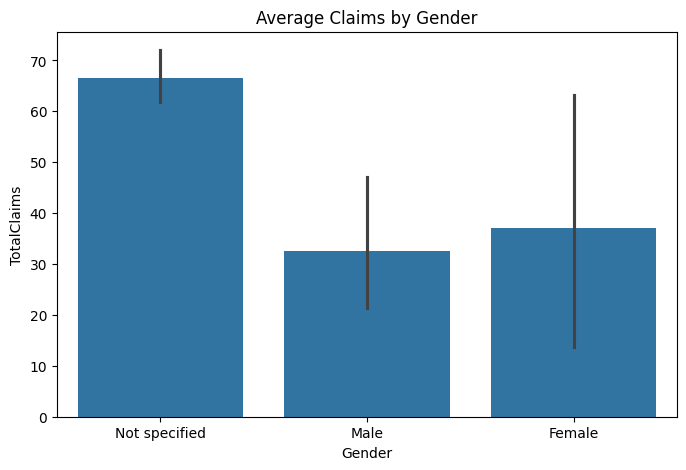

In [37]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Gender",
    y="TotalClaims"
)

plt.title(
    "Average Claims by Gender"
)

plt.show()

# Interpretation: Average Claims by Gender

This bar chart compares the average insurance claim amounts (TotalClaims) between male and female policyholders.
-  What the Chart Shows
-  The x-axis represents customer gender.
-  The y-axis represents the average claim amount.
-  Each bar shows the mean claim severity for that gender group.

### Interpretation:

That gender group tends to generate higher average insurance claims, suggesting potentially greater claim severity or higher-risk driving behavior.
-  Possible contributing factors include:

-->  driving exposure
-->  vehicle usage patterns
-->  accident frequency
-->  vehicle type differences
# Business Significance

### Gender-based claim analysis can help insurers:

-  assess demographic risk patterns
-  support underwriting segmentation
-  evaluate fairness in premium pricing
-  inform future hypothesis testing

### However, pricing decisions should also consider:

-  regulatory constraints
-  fairness considerations
-  statistical significance testing
# Generall Interpritation  
The gender-based claim analysis compares average claim severity across male and female policyholders. The visualization suggests that one gender may exhibit slightly higher average claim amounts; however, the observed difference alone does not confirm statistical significance. Additional hypothesis testing is required to determine whether gender meaningfully influences insurance risk exposure and profitability.

# Margin Distribution

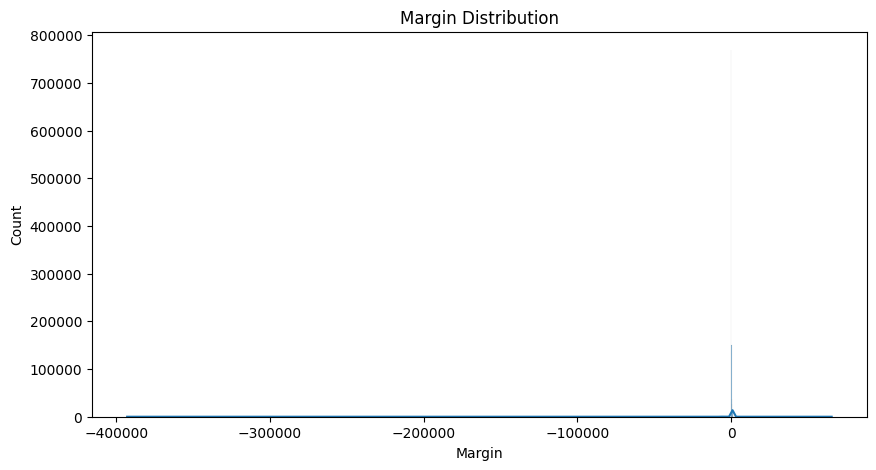

In [40]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Margin"],
    kde=True
)

plt.title(
    "Margin Distribution"
)

plt.show()

# Important Analytical Insight

This graph suggests that:

mean values alone may be misleading
robust statistics (median, IQR, percentiles) are important
outlier handling or log transformation may improve interpretability
# Generall Interpritation

The margin distribution exhibits substantial skewness and extreme negative outliers, indicating that a small subset of policies generated disproportionately large underwriting losses. Most policies appear clustered near modest profit or loss values, while several catastrophic claims produced severe negative margins. This heavy-tailed distribution is characteristic of insurance financial data and highlights the importance of robust risk management and outlier-aware pricing strategies.

-  However this histogram is difficult to interpret because of the extreme outliers.

A better professional visualization would be:

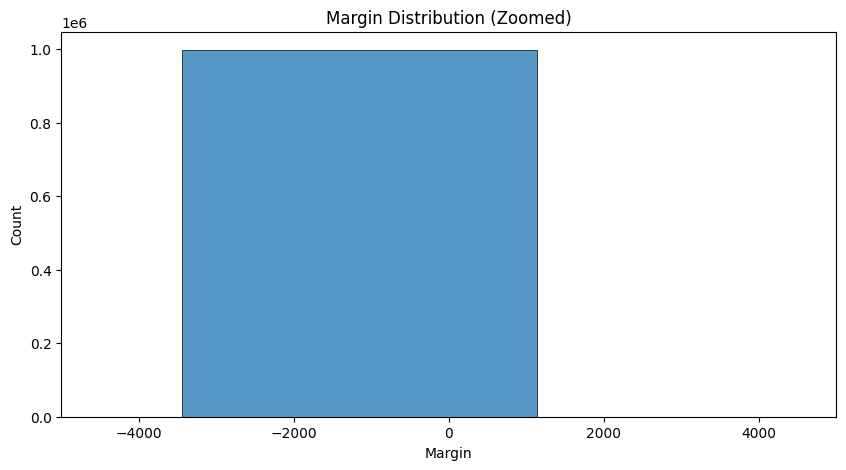

In [41]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Margin"],
    bins=100
)

plt.xlim(-5000, 5000)

plt.title("Margin Distribution (Zoomed)")
plt.xlabel("Margin")

plt.show()

This zooms into the region where most observations exist and makes the distribution much clearer.

# Better Option: Boxplot

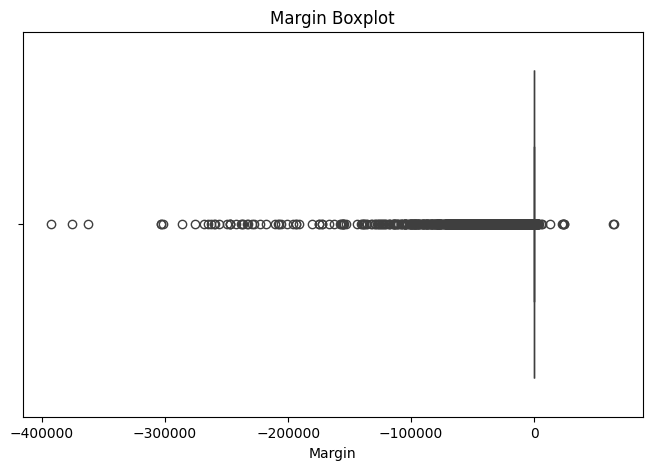

In [42]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Margin"])

plt.title("Margin Boxplot")

plt.show()

A boxplot is often more informative for insurance financial variables because it clearly highlights:

-  median profitability
-  spread
-  extreme outliers
-  skewness

# Margin Boxplot Interpretation

The margin boxplot provides a summary of the distribution of insurer profitability, where margin is calculated as:

-  Margin = TotalPremium − TotalClaims

The visualization reveals that the margin data is highly skewed and contains numerous extreme outliers, particularly on the negative side. This indicates that while many insurance policies generate moderate profits or balanced outcomes, a smaller number of policies experience exceptionally large claim costs that exceed collected premiums and produce substantial underwriting losses.

The wide spread of the boxplot suggests considerable variability in profitability across policies. The presence of extreme negative outliers highlights exposure to rare but high-severity insurance events, which can significantly impact overall financial performance.

Such heavy-tailed distributions are common in insurance analytics because catastrophic claims tend to disproportionately affect profitability metrics. These findings emphasize the importance of robust pricing strategies, risk segmentation, reserve management, and outlier-aware statistical modeling in insurance operations.